<a href="https://colab.research.google.com/github/Mohana-27/Fraud-Transaction-Analysis/blob/main/Fraud_Transaction_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fraud Transaction Data Analysis**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

I loaded the dataset into a dataframe called transaction which contains transaction details like transaction_id, transaction_time, transaction_amount, location, device_type, merchant_id, card_holder_age and is_fraud




In [ ]:
transaction=pd.read_excel('/content/fraud_transactions_300_records.xlsx')

I loaded the dataset into transaction for analysis

In [ ]:
transaction

,transaction_id,transaction_time,transaction_amount,location,device_type,merchant_id,card_holder_age,is_fraud
0,TX100000,2025-01-11 23:15:00,2926.82,Hyderabad,Web,M9519,45,0
1,TX100001,2025-01-01 14:20:00,89.17,Kolkata,Web,M8221,50,0
2,TX100002,2025-01-27 11:58:00,10424.47,Chennai,Web,M4310,65,1
3,TX100003,2025-01-08 20:04:00,1269.55,Kolkata,POS,M4300,58,0
4,TX100004,2025-01-05 08:25:00,655.79,Chennai,Mobile,M7722,30,0
...,...,...,...,...,...,...,...,...
295,TX100295,2025-01-21 05:24:00,4887.51,Hyderabad,POS,M2312,49,0
296,TX100296,2025-01-20 04:43:00,1759.67,Hyderabad,ATM,M5311,68,0
297,TX100297,2025-01-29 07:24:00,2590.14,Hyderabad,ATM,M8314,61,0
298,TX100298,2025-01-07 06:07:00,2830.06,Delhi,ATM,M3383,35,0


In [ ]:
transaction.describe()

,transaction_time,transaction_amount,card_holder_age,is_fraud
count,300,300.000000,300.000000,300.000000
mean,2025-01-15 04:36:35.800000,1982.604467,43.190000,0.060000
min,2025-01-01 02:41:00,10.400000,18.000000,0.000000
25%,2025-01-06 21:45:00,577.252500,30.750000,0.000000
50%,2025-01-15 18:17:00,1284.315000,43.500000,0.000000
75%,2025-01-22 05:46:15,2671.595000,55.000000,0.000000
max,2025-01-30 21:01:00,11008.830000,69.000000,1.000000
std,NaN,2029.649616,14.387398,0.237884


In [ ]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      300 non-null    object        
 1   transaction_time    300 non-null    datetime64[ns]
 2   transaction_amount  300 non-null    float64       
 3   location            300 non-null    object        
 4   device_type         300 non-null    object        
 5   merchant_id         300 non-null    object        
 6   card_holder_age     300 non-null    int64         
 7   is_fraud            300 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 18.9+ KB


I used describe() and info() to understand the dataset structure


In [ ]:
#creating fraud risk features
def risk_level(transaction):
    if transaction["transaction_amount"] > 3000 and transaction["device_type"] == "Mobile":
        return "High Risk"
    elif transaction["transaction_amount"] > 1000:
        return "Medium Risk"
    else:
        return "Low Risk"

transaction["risk_level"] = transaction.apply(risk_level, axis=1)

I used transaction_amount to create a new column called risk_level.

In [ ]:
transaction

,transaction_id,transaction_time,transaction_amount,location,device_type,merchant_id,card_holder_age,is_fraud,risk_level
0,TX100000,2025-01-11 23:15:00,2926.82,Hyderabad,Web,M9519,45,0,Medium Risk
1,TX100001,2025-01-01 14:20:00,89.17,Kolkata,Web,M8221,50,0,Low Risk
2,TX100002,2025-01-27 11:58:00,10424.47,Chennai,Web,M4310,65,1,Medium Risk
3,TX100003,2025-01-08 20:04:00,1269.55,Kolkata,POS,M4300,58,0,Medium Risk
4,TX100004,2025-01-05 08:25:00,655.79,Chennai,Mobile,M7722,30,0,Low Risk
...,...,...,...,...,...,...,...,...,...
295,TX100295,2025-01-21 05:24:00,4887.51,Hyderabad,POS,M2312,49,0,Medium Risk
296,TX100296,2025-01-20 04:43:00,1759.67,Hyderabad,ATM,M5311,68,0,Medium Risk
297,TX100297,2025-01-29 07:24:00,2590.14,Hyderabad,ATM,M8314,61,0,Medium Risk
298,TX100298,2025-01-07 06:07:00,2830.06,Delhi,ATM,M3383,35,0,Medium Risk


In [ ]:
mean_transaction_amount = transaction['transaction_amount'].mean()
mean_transaction_amount

np.float64(1982.604466666667)

I calculated the mean using transaction_amount to know average transaction.

In [ ]:
sum_is_fraud = transaction['is_fraud'].sum()
sum_is_fraud

np.int64(18)

I calculated the total using is_fraud to understand overall transaction fraud.

In [ ]:
max_card_holder_age = transaction['card_holder_age'].max()
max_card_holder_age

69

I found the maximum value using card_holder_age to identify highest age.

In [ ]:
min_transaction_amount = transaction['transaction_amount'].min()
min_transaction_amount

10.4

I found the minimum value using transaction_amount to identify lowest amount.

In [ ]:
transaction_id=transaction['transaction_id'].count()
transaction_id

np.int64(300)

I used transaction_id to count total number of transaction.

In [ ]:
transaction.groupby('risk_level')['is_fraud'].max()

,is_fraud
risk_level,
High Risk,1
Low Risk,1
Medium Risk,1


I used is_fraud and risk_level to compare performance.

In [ ]:
transaction.groupby('merchant_id')['risk_level'].min()


,risk_level
merchant_id,
M1060,Medium Risk
M1074,Medium Risk
M1130,Medium Risk
M1145,Medium Risk
M1153,Medium Risk
...,...
M9930,Low Risk
M9942,Medium Risk
M9966,Low Risk


I used merchant_id and risk_level to analyze the fraud impact.

**Exploratory Data Analysis**(EDA)

**Univariate**

In univariate analysis, I analyzed one column at a time to focus on a single variable without comparing it to others.


<Axes: xlabel='transaction_amount', ylabel='Count'>

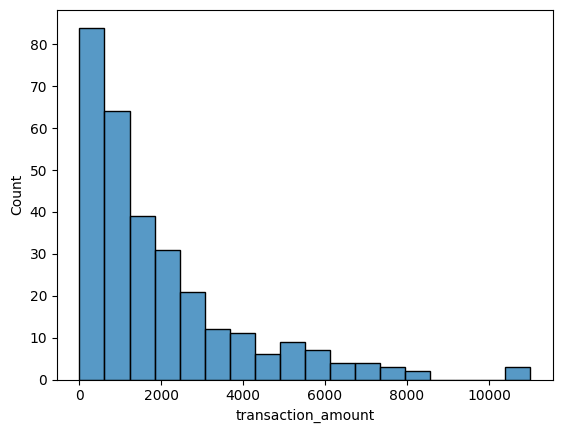

In [ ]:
#univariate analysis
#histogram
sns.histplot(transaction["transaction_amount"])

I used transaction_amount to understand distribution of transaction values.

<Axes: ylabel='card_holder_age'>

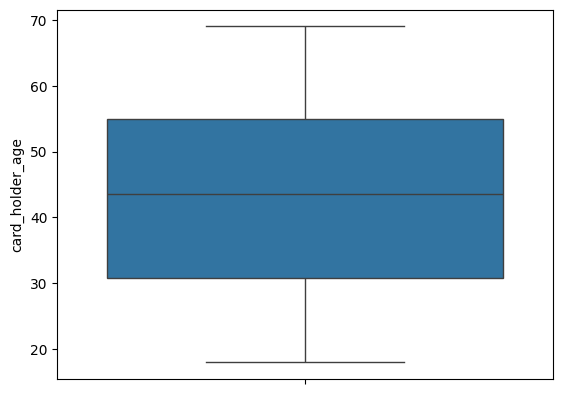

In [ ]:
#boxplot
sns.boxplot(transaction["card_holder_age"])

I used card_holder_age to analyze spread and extreme value.

**Bivariate Analysis**

I used bivariate analysis to study the relationship between two variables, helping me see how one affects the other and find patterns using charts like scatter plots and boxplots.

<Axes: xlabel='is_fraud', ylabel='transaction_amount'>

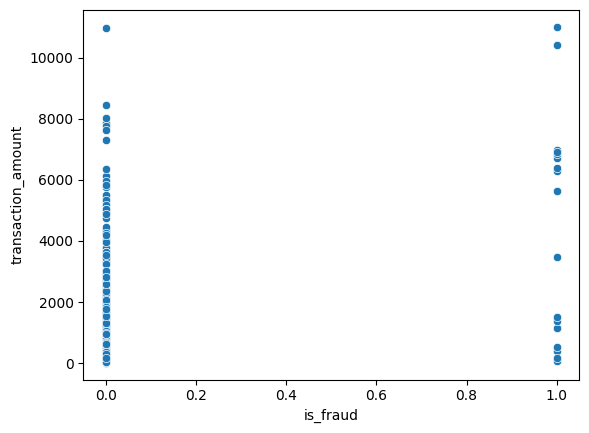

In [ ]:
#bivariate analysis
#scatter chart
sns.scatterplot(x=transaction["is_fraud"],y=transaction["transaction_amount"])

I used is_fraud and transaction_amount to see their relationship.

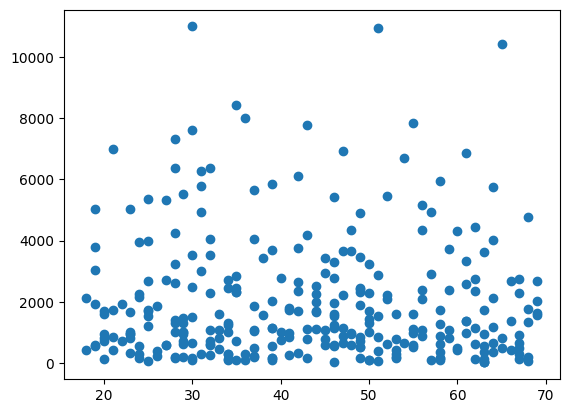

In [ ]:
#scatter chart by matplotlib
plt.scatter(x=transaction["card_holder_age"],y=transaction["transaction_amount"])

I used card_holder_age and transaction_amount to visualize the relation.

<Axes: xlabel='device_type', ylabel='transaction_amount'>

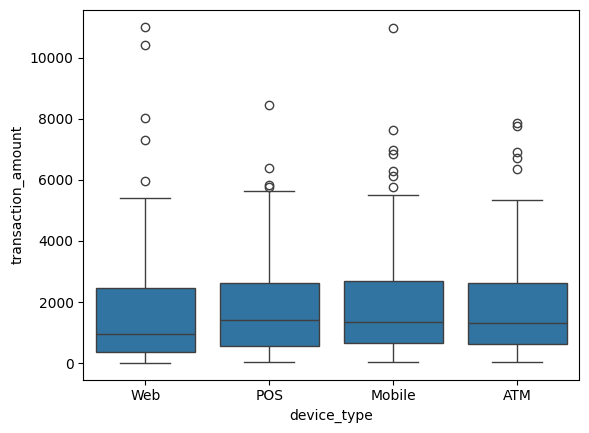

In [ ]:
#boxplot-bivariate analysis
sns.boxplot(x=transaction["device_type"], y=transaction["transaction_amount"])

I used device_type and transaction_amount to compare values.

**MultiVariate Analysis**

I performed multivariate analysis to study how multiple variables work together, helping me understand how different factors influence transactions, using tools like heatmaps and pairplots to find patterns.


In [ ]:
x=transaction.drop(columns=["is_fraud", "risk_level"],axis=1)
x

,transaction_id,transaction_time,transaction_amount,location,device_type,merchant_id,card_holder_age
0,TX100000,2025-01-11 23:15:00,2926.82,Hyderabad,Web,M9519,45
1,TX100001,2025-01-01 14:20:00,89.17,Kolkata,Web,M8221,50
2,TX100002,2025-01-27 11:58:00,10424.47,Chennai,Web,M4310,65
3,TX100003,2025-01-08 20:04:00,1269.55,Kolkata,POS,M4300,58
4,TX100004,2025-01-05 08:25:00,655.79,Chennai,Mobile,M7722,30
...,...,...,...,...,...,...,...
295,TX100295,2025-01-21 05:24:00,4887.51,Hyderabad,POS,M2312,49
296,TX100296,2025-01-20 04:43:00,1759.67,Hyderabad,ATM,M5311,68
297,TX100297,2025-01-29 07:24:00,2590.14,Hyderabad,ATM,M8314,61
298,TX100298,2025-01-07 06:07:00,2830.06,Delhi,ATM,M3383,35


I removed is_fraud and risk_level for analysis.

<Axes: >

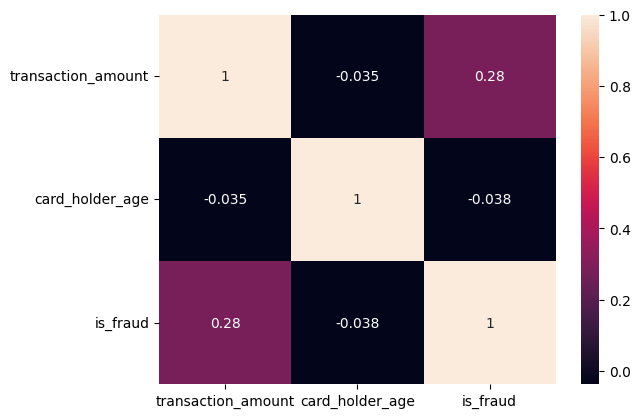

In [ ]:
#multivariate analysis
#heatmap
sns.heatmap(transaction.select_dtypes(include=["number"]).corr(), annot=True)

I used numerical columns like transaction_amount, card_holder_age, and is_fraud to find relationships.

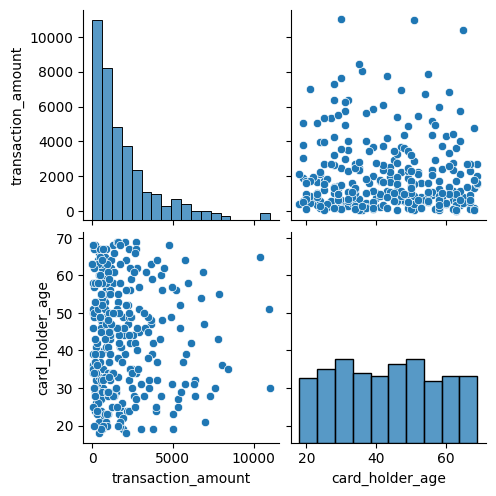

In [ ]:
#pairplot
sns.pairplot(x)


I used the same columns to visualize patterns and relationships in pair plot

In [ ]:
transaction.to_csv("Fraud Transaction Data.csv")

**Final Summary**

In this project, I analyzed the transaction dataset using Python to understand transaction patterns and fraud detection. I created a new risk_level column using transaction_amount to classify transactions. I calculated values like mean, sum, max, and min using columns such as transaction_amount, card_holder_age, and is_fraud to understand overall patterns. I used groupby with is_fraud and risk_level to analyze how device usage affects fraud.

I performed univariate analysis using transaction_amount and card_holder_age and bivariate analysis using card_holder_age and transaction_amount to study relationships. Finally, I used multivariate analysis with heatmap and pairplot to understand how multiple factors like amount and age are related. Overall, this project helped me identify patterns in transactions and understand how different factors influence fraud detection.
